In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import datetime

/nesi/project/niwa00018/queenle/ml_env_v2/lib/python3.8/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)

In [3]:
# load input variable datasets
print('loading datasets')
d4pdf_vars = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/FWI_inputs_HPB_ensMean_1951-2021.nc')
d4pdf_bc_wind = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/BC_wind/BC_WIND_HPB_ensMean_1951-2021.nc')
d4pdf_bc_wind = d4pdf_bc_wind.rename({'latitude':'lat','longitude':'lon'})
d4pdf_vars['bc_wind'] = d4pdf_bc_wind

era5_d4pdf_res = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/daily/d4pdf_resolution/FWI_inputs_daily_d4pdf_resolution.nc')

# create vege masks 
vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]
era5_combined = (vege_ds.lai_hv + vege_ds.lai_lv).max('time')
era5_vege_mask = era5_combined.where(era5_combined>3.5)

vege_ds_coarsened = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()

d4pdf_vege = vege_ds_coarsened.interp(longitude=d4pdf_vars.lon, latitude=d4pdf_vars.lat, method="linear")
d4pdf_combined = (d4pdf_vege.lai_hv + d4pdf_vege.lai_lv).max('time')
d4pdf_vege_mask = d4pdf_combined.where(d4pdf_combined>3.5)

# clip to study region
print('mask by vegetation and clip to region')
box = [(32,55),(232,256)]

d4pdf_vars = d4pdf_vars.where(d4pdf_vege_mask>0).sel(lat=slice(box[0][0],box[0][1]),lon=slice(box[1][0],box[1][1]))
era5_d4pdf_res = era5_d4pdf_res.where(d4pdf_vege_mask>0).sel(lat=slice(box[0][0],box[0][1]),lon=slice(box[1][0],box[1][1]))


loading datasets
mask by vegetation and clip to region


In [4]:
d4pdf_means = d4pdf_vars.mean('time')
era5_d4pdf_means = era5_d4pdf_res.mean('time')

d4pdf_wind_trend = xr.apply_ufunc(get_linregress_slope, d4pdf_vars['wind'], input_core_dims=[["time"]], vectorize = True)*365
d4pdf_bcwind_trend = xr.apply_ufunc(get_linregress_slope, d4pdf_vars['bc_wind'], input_core_dims=[["time"]], vectorize = True)*365
era5_wind_trend = xr.apply_ufunc(get_linregress_slope, era5_d4pdf_res['wind'], input_core_dims=[["time"]], vectorize = True)*365


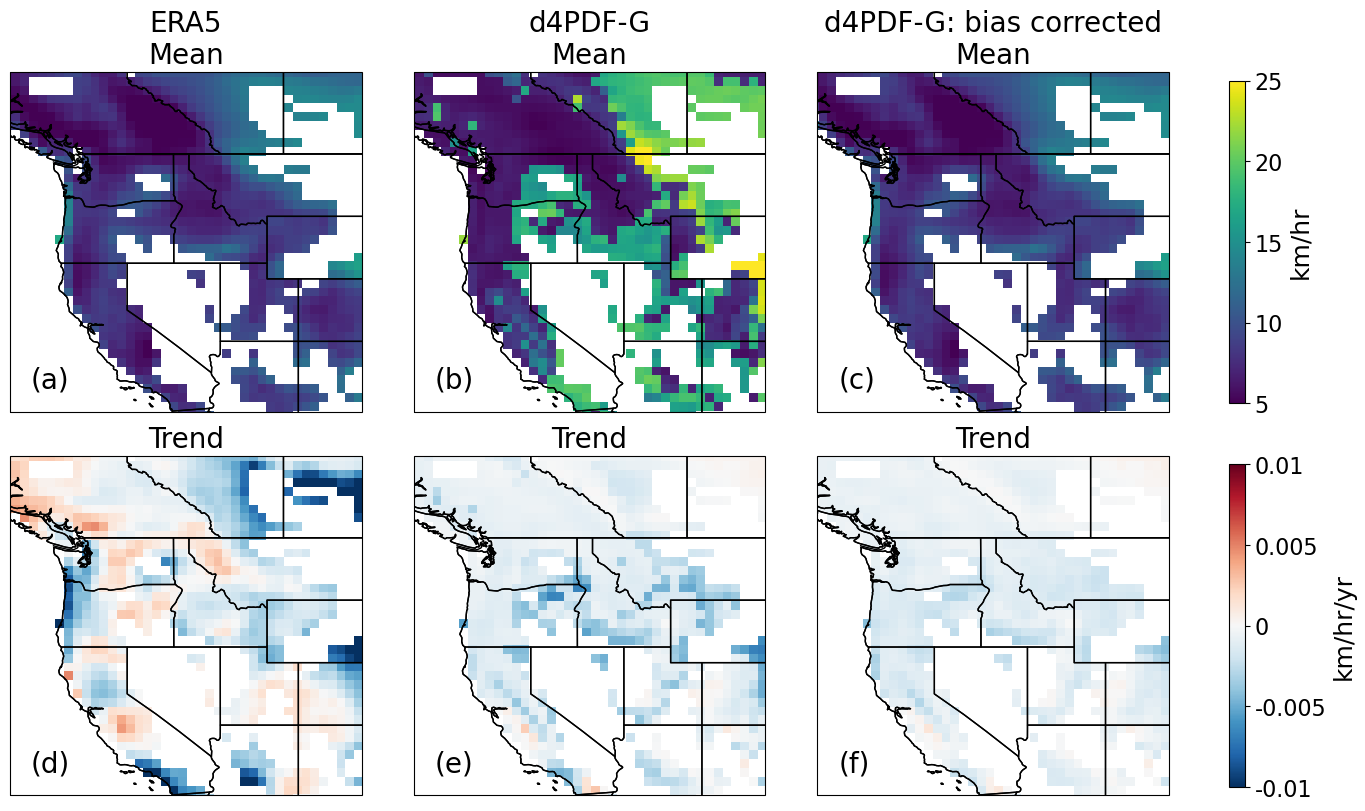

In [6]:
'''
d4pdf WIND bias correction plots
'''

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 20,
        }

fig,axs = plt.subplots(2,3,figsize=(14,8),layout='constrained',subplot_kw=dict(projection=ccrs.PlateCarree()))
axs = axs.flatten()

mean_das = [era5_d4pdf_means['wind'],d4pdf_means['wind'],d4pdf_means['bc_wind']]
trend_das = [era5_wind_trend,d4pdf_wind_trend,d4pdf_bcwind_trend]

titles = ['ERA5','d4PDF-G', 'd4PDF-G: bias corrected']
labels = ['a','b','c','d','e','f','g','h']

for i in range(len(mean_das)):
    # mean
    mean_im = mean_das[i].plot(ax=axs[i],vmin=5,vmax=25,add_colorbar=False)
    axs[i].set_title(titles[i] + '\nMean',fontdict=font)
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')
    
    # trend
    trend_im = trend_das[i].plot(ax=axs[i+3],vmin=-.01,vmax=0.01,cmap='RdBu_r',add_colorbar=False)
    axs[i+3].set_title('Trend',fontdict=font)
    axs[i+3].set_ylabel('')
    axs[i+3].set_xlabel('')
    
for i,ax in enumerate(axs):
    ax.coastlines()
    ax.add_feature(cf.BORDERS)
    ax.add_feature(cf.STATES)
    ax.set_extent([232.5,255, 32.5,54.18])#, crs=noproj)
    ax.text(0.06,0.07,'('+labels[i]+')',transform=ax.transAxes,fontdict=font)

mean_cb = fig.colorbar(mean_im, ax=axs[:3], shrink=0.95, orientation='vertical')
font['size'] = 18
mean_cb.set_label(label='km/hr',fontdict=font)
font['size']=16
mean_cb.set_ticks([5,10,15,20,25],labels=[str(val) for val in [5,10,15,20,25]],fontdict=font)

trend_cb = fig.colorbar(trend_im, ax=axs[3:6], shrink=0.95, orientation='vertical')
font['size'] = 18
trend_cb.set_label(label='km/hr/yr',fontdict=font)
font['size']=16
trend_cb.set_ticks([-0.01,-0.005,0,0.005,0.01],labels=[str(val) for val in [-0.01,-0.005,0,0.005,0.01]],fontdict=font)

plt.savefig(f'/home/queenle/fire_attribution/figures/sup_mat/SM_Fig5.png',dpi=300)


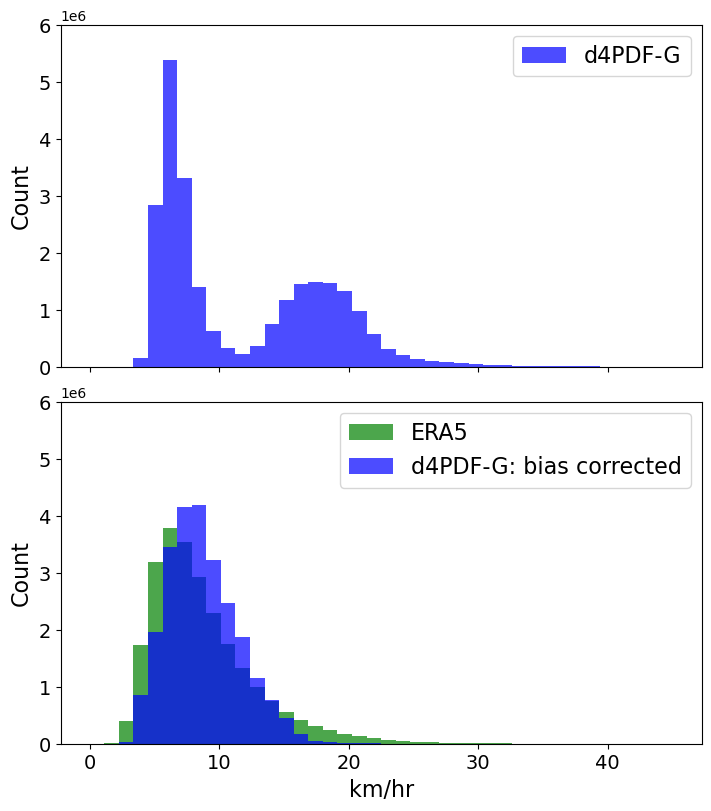

In [8]:
fig,axs = plt.subplots(2,1,figsize=(7,8),layout='constrained',sharex=True)

axs[0].hist(d4pdf_vars['wind'].data.flatten(),40,range=[0,45],color='blue',alpha=0.7,label='d4PDF-G')
axs[0].legend(fontsize=16)

axs[1].hist(era5_d4pdf_res['wind'].data.flatten(),40,range=[0,45],color='green',alpha=0.7,label='ERA5')
axs[1].hist(d4pdf_vars['bc_wind'].data.flatten(),40,range=[0,45],color='blue',alpha=0.7,label='d4PDF-G: bias corrected')
axs[1].legend(fontsize=16)

axs[1].set_xticks([0,10,20,30,40])
axs[1].set_xticklabels([str(val) for val in [0,10,20,30,40]],fontdict=font)
axs[1].set_xlabel('km/hr',fontdict=font)

for ax in axs:
    ax.set_ylabel('Count',fontdict=font)
    
    ax.set_yticks([0, 1000000, 2000000, 3000000, 4000000, 5000000,6000000])
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

    ax.tick_params(axis='both', which='major', labelsize=14)

plt.savefig(f'/home/queenle/fire_attribution/figures/sup_mat/SM_Fig6.png',dpi=300)
